# Grunnlag: fra referansemodell til maskinlæring

Arbeidsverk 2, notebook 01. Bygger på rapporten fra arbeidsverk 1 —
`bostotte_oslo.pdf` i [Torcode/bostotte-oslo](https://github.com/Torcode/bostotte-oslo).

Notebooken knytter analysen til et datert uttrekk, går gjennom variablene og hva
de tåler, viser hvilke fordelinger som ligger bak aggregatene, og regner ut hvor
mye informasjon panelet inneholder.

Ingen modell estimeres her. Panelets størrelse avgjør hvilke modellklasser som er
aktuelle, så det tallet kommer først.

**Om figurer og tabeller.** Hver figur har tallene sine trykket ved siden av seg,
og for hver oppgis hvilken bevegelse som er for liten til å tolkes. Der en figur
viser et gjennomsnitt, står det hvilken fordeling over husstander som kan
produsere bildet.

**Om arbeidsformen.** Prosjektet er skrevet med KI som verktøy. Tall i teksten
kommer fra celler som kjører. Kildene har en statustabell i avsnitt 8.


## 1. Innledning

*Til Torkild: skrives ut i din egen stemme, omtrent én side. Punktene er
innholdet, ikke formuleringene.*

1. **Der arbeidsverk 1 endte.** Serien er regelstyrt. Betinget på tre
   intervensjonsvinduer og to kalenderregressorer er logserien stasjonær.
   Hovedspesifikasjonen traff termin april 2024 — et fall på 25 % på én termin —
   innenfor 3 % fra ni måneders horisont. Sesongnaiv og SARIMA bommet med 25–35 %.
2. **To av fem implikasjoner falt.** T4 falt motsatt vei av forventningen:
   modellering av bruddene forverret intervalldekningen. T5 lot seg ikke teste,
   fordi det ikke finnes publiserte husstandstall for hendelsen det gjaldt.
3. **Et funn som peker framover.** Inngangsregelen slipper en regressor inn så
   snart den er teknisk estimerbar, men estimatet er svært upresist i månedene
   etter. Det finnes tre regimer: uidentifiserbar, identifisert men upålitelig,
   og identifisert og stabil. Arbeidsverk 1 skiller bare det første fra de to siste.
4. **Hvorfor Python nå.** Baselinen er bygget i R, der tidsserieverktøyet bor.
   Modellklassene som gjenstår hører hjemme i Python.
5. **Hva spørsmålet er.** Ikke om maskinlæring slår en referansemodell på én
   serie med 198 månedsobservasjoner. Avsnitt 7 gjengir hvorfor svaret på det er
   nei. Spørsmålet er om strukturen i datagrunnlaget bærer informasjon en
   enkeltseriemodell ikke når.
6. **Din egen linje inn:** hvorfor bydelsnivået er det etaten dimensjonerer på,
   og hva prognosen skal brukes til.


## 2. Oppsett og datering

Husbanken publiserer nye månedstall løpende, og reviderer bakover ved
etterkontroll mot skatteoppgjøret. Et resultat må derfor kunne knyttes til den
tilstanden dataene hadde da det ble laget.

Uttrekksskriptet kjører mot Husbankens API og lagrer hvert uttrekk i en datert
mappe. En analyse oppgir hvilken dato den bygger på, og kontrollerer sjekksummene
til filene den leser før den regner. Kontrollen kan feile; det er poenget med den.

Denne notebooken leser uttrekket som følger commit `9b3da3e`, datert
4. august 2026.


In [1]:
COMMIT   = "9b3da3e"        # arbeidsverk 1, 6. august 2026
UTTREKK  = "2026-08-04"     # datoen datagrunnlaget er hentet
REPO     = "https://github.com/Torcode/bostotte-oslo.git"

import os, subprocess

# Colab legger alt under /content; utenfor Colab klones det til arbeidsmappa.
MAPPE = "/content/bostotte-oslo" if os.path.isdir("/content") else "bostotte-oslo"

if not os.path.isdir(MAPPE):
    subprocess.run(["git", "clone", "-q", "--depth", "1", REPO, MAPPE], check=True)
os.chdir(MAPPE)

def hode():
    return subprocess.run(["git", "rev-parse", "--short", "HEAD"],
                          capture_output=True, text=True).stdout.strip()

if hode() != COMMIT:                       # main kan ha flyttet seg
    subprocess.run(["git", "fetch", "-q", "--depth", "1", "origin", COMMIT], check=True)
    subprocess.run(["git", "checkout", "-q", COMMIT], check=True)

assert hode() == COMMIT, f"Forventet {COMMIT}, fikk {hode()}"
print("arbeidsmappe :", os.getcwd())
print("commit       :", hode())
print("uttrekk      :", UTTREKK)


arbeidsmappe : /content/bostotte-oslo
commit       : 9b3da3e
uttrekk      : 2026-08-04


### Sjekksummer

Sjekksummene under er regnet av notebooken. Når datagrunnlaget flyttes til
daterte mapper, leses de i stedet fra uttrekkets eget manifest og sammenliknes,
slik at en endret fil stopper kjøringen framfor å passere ubemerket.


In [2]:
import hashlib, json
import pandas as pd

RAW    = "data/raw/"
FILER  = ["husbanken_bostotte_oslo_manedlig.csv",
          "husbanken_bostotte_oslo_bydel_manedlig.csv",
          "husbanken_bostotte_oslo_brukergruppe_manedlig.csv"]

def sha256(sti, blokk=1 << 20):
    h = hashlib.sha256()
    with open(sti, "rb") as f:
        for b in iter(lambda: f.read(blokk), b""):
            h.update(b)
    return h.hexdigest()

SJEKKSUM = {f: sha256(RAW + f) for f in FILER}
pd.DataFrame({"fil": FILER,
              "bytes": [os.path.getsize(RAW + f) for f in FILER],
              "sha256": [SJEKKSUM[f][:16] + "..." for f in FILER]})


,fil,bytes,sha256
0,husbanken_bostotte_oslo_manedlig.csv,15072,5e741e0864bd8d66...
1,husbanken_bostotte_oslo_bydel_manedlig.csv,231775,d5dcd738bb9e23cc...
2,husbanken_bostotte_oslo_brukergruppe_manedlig.csv,90048,3b0f170c2e876364...


### Miljøstempel

Colab bytter pakkeversjoner uten varsel. Stempelet noterer hvilke versjoner som
produserte tallene.


In [3]:
import platform, importlib

MANIFEST = {"commit": COMMIT, "uttrekk": UTTREKK,
            "python": platform.python_version(),
            "pakker": {}, "sjekksum": SJEKKSUM}
for p in ["numpy", "pandas", "sklearn", "scipy", "matplotlib"]:
    try:    MANIFEST["pakker"][p] = importlib.import_module(p).__version__
    except ImportError: MANIFEST["pakker"][p] = None

print(json.dumps({k: MANIFEST[k] for k in ["commit","uttrekk","python","pakker"]},
                 indent=2))


{
  "commit": "9b3da3e",
  "uttrekk": "2026-08-04",
  "python": "3.11.15",
  "pakker": {
    "numpy": "2.4.4",
    "pandas": "3.0.2",
    "sklearn": "1.8.0",
    "scipy": "1.17.1",
    "matplotlib": "3.10.9"
  }
}


In [4]:
import numpy as np, matplotlib.pyplot as plt

SEED = 20260807
np.random.seed(SEED)
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)

# Kategorisk palett med validert rekkefølge: verste nabopar har dE 9.1 ved
# protanopi og 19.6 for normalsyn. Tre av slottene ligger under 3:1 kontrast mot
# hvit flate, og krever derfor synlige etiketter eller tall ved siden av figuren.
SERIE   = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
BLEKK, BLEKK_2, DEMPET = "#0b0b0b", "#52514e", "#898781"
RUTE, BASIS = "#e1e0d9", "#c3c2b7"
NB, HARDT = chr(10), chr(160)

plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 130, "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "font.size": 8.5, "axes.titlesize": 9.5, "axes.titleweight": "semibold",
    "axes.titlelocation": "left", "axes.titlepad": 8,
    "text.color": BLEKK, "axes.labelcolor": BLEKK_2,
    "xtick.color": DEMPET, "ytick.color": DEMPET,
    "xtick.labelcolor": BLEKK_2, "ytick.labelcolor": BLEKK_2,
    "axes.edgecolor": BASIS, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": RUTE, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "legend.frameon": False, "legend.fontsize": 7.5,
    "lines.linewidth": 1.6, "lines.solid_capstyle": "round",
})

def tusen(v, _=None):
    return f"{v:,.0f}".replace(",", HARDT)

print("seed satt, figurstil satt")


seed satt, figurstil satt


## 3. Dataene og variablene

Uttrekket har tre nivåer av samme størrelse: Oslo totalt, Oslo fordelt på 15
bydeler pluss en ufordelt restnode, og Oslo fordelt på 5 brukergrupper. Alle tre
kommer fra Husbankens statistikkbank, hentet med Qlik Engine-API-et.


In [5]:
def les(fil, nøkler):
    d = pd.read_csv(RAW + fil, dtype={"kommunenr": str})
    d["dato"] = pd.to_datetime(dict(year=d.aar, month=d.manedsnr, day=1))
    return d.sort_values(nøkler + ["dato"]).reset_index(drop=True)

oslo  = les(FILER[0], [])
bydel = les(FILER[1], ["kommunenr"])
bgr   = les(FILER[2], ["brukergruppe"])

for navn, d in [("oslo", oslo), ("bydel", bydel), ("brukergruppe", bgr)]:
    print(f"{navn:13s} {len(d):6d} rader   {d.dato.min():%Y-%m} – {d.dato.max():%Y-%m}")


oslo             199 rader   2010-01 – 2026-07
bydel           3022 rader   2010-01 – 2026-07
brukergruppe     995 rader   2010-01 – 2026-07


### Hva én rad er

Én rad er én måned for én enhet. Utfallsvariabelen er `ant_husstander_termin`,
antall unike husstander med positivt terminvedtak for måneden.

To kalendre må holdes fra hverandre:

| Kalender | Kolonne | Hva den daterer |
|---|---|---|
| Termin | `ant_husstander_termin` | måneden vedtaket gjelder |
| Utbetaling | `ant_husstander_utbetaling` | måneden pengene utbetales, den 20. måneden etter |

Arbeidsverk 1 modellerer terminkalenderen. Den svarer på hvor mange husstander
som har rett til bostøtte en gitt måned.

Forvekslingen er ikke hypotetisk. SØF-rapport 05/2025 daterer avviklingen av det
midlertidige regelverket til mai 2024; dette arbeidet daterer den til termin
april 2024. Begge er riktige, fordi termin april utbetales 20. mai. To kilder
omtaler samme hendelse med én måneds forskjell, og forskjellen er hvilken
kalender de bruker.

Cellen kontrollerer identiteten mellom de to.


In [6]:
k = oslo[["dato", "ant_husstander_termin", "ant_husstander_utbetaling"]].copy()
k["utb_neste"]  = k["ant_husstander_utbetaling"].shift(-1)
k["differanse"] = k["ant_husstander_termin"] - k["utb_neste"]
t = k.dropna(subset=["utb_neste"]).query("ant_husstander_termin > 0")

print(f"måneder testet           : {len(t)}")
print(f"måneder med differanse 0 : {(t.differanse == 0).sum()}")
print(f"største avvik            : {t.differanse.abs().max():.0f}")
assert (t.differanse == 0).all(), "Kalenderidentiteten holder ikke"


måneder testet           : 198
måneder med differanse 0 : 198
største avvik            : 0


### Variablene, og hva de tåler

To av kolonnene er ikke selvstendig informasjon, og fire er gjennomsnitt over en
gruppe hvis grense settes av regelverket. Avsnitt 4 viser hva det siste betyr i
praksis.


In [7]:
pd.DataFrame([
 ("ant_husstander_termin",    "beholdning", "utfall",
  "Prognoseobjektet. Nivået er resultatet av inn- og utstrømning."),
 ("ant_husstander_utbetaling","beholdning", "kalenderkontroll",
  "Samme størrelse forskjøvet én måned."),
 ("ant_soknader",             "strøm",      "ikke prediktor",
  "Behandlede saker = innvilget + avslag. Lineærkombinasjon av utfallet."),
 ("ant_avslag",               "strøm",      "diagnostikk",
  "Del av samme identitet."),
 ("utbetalt_belop",           "sum",        "sekundærutfall",
  "Måler omregnet rett, ikke utbetalt kasse."),
 ("gjsnitt_bostotte",         "snitt",      "grensesensitiv",
  "Snitt over mottakerne. Følger hvor regelverket setter grensen."),
 ("gjsnitt_inntekt_mnd",      "snitt",      "grensesensitiv", "Samme."),
 ("gjsnitt_boutgift_mnd",     "snitt",      "grensesensitiv", "Samme."),
 ("ant_over_tak",             "antall",     "grensesensitiv",
  "Avhenger av takets nivå og av hvem som er innenfor."),
], columns=["kolonne", "type", "rolle", "merknad"])


,kolonne,type,rolle,merknad
0,ant_husstander_termin,beholdning,utfall,Prognoseobjektet. Nivået er resultatet av inn-...
1,ant_husstander_utbetaling,beholdning,kalenderkontroll,Samme størrelse forskjøvet én måned.
2,ant_soknader,strøm,ikke prediktor,Behandlede saker = innvilget + avslag. Lineærk...
3,ant_avslag,strøm,diagnostikk,Del av samme identitet.
4,utbetalt_belop,sum,sekundærutfall,"Måler omregnet rett, ikke utbetalt kasse."
5,gjsnitt_bostotte,snitt,grensesensitiv,Snitt over mottakerne. Følger hvor regelverket...
6,gjsnitt_inntekt_mnd,snitt,grensesensitiv,Samme.
7,gjsnitt_boutgift_mnd,snitt,grensesensitiv,Samme.
8,ant_over_tak,antall,grensesensitiv,Avhenger av takets nivå og av hvem som er inne...


## 4. Aggregatet og fordelingen bak

Figuren viser antall mottakere og gjennomsnittlig månedsinntekt blant dem. De to
seriene har hver sin skala og står derfor i hver sin rute.


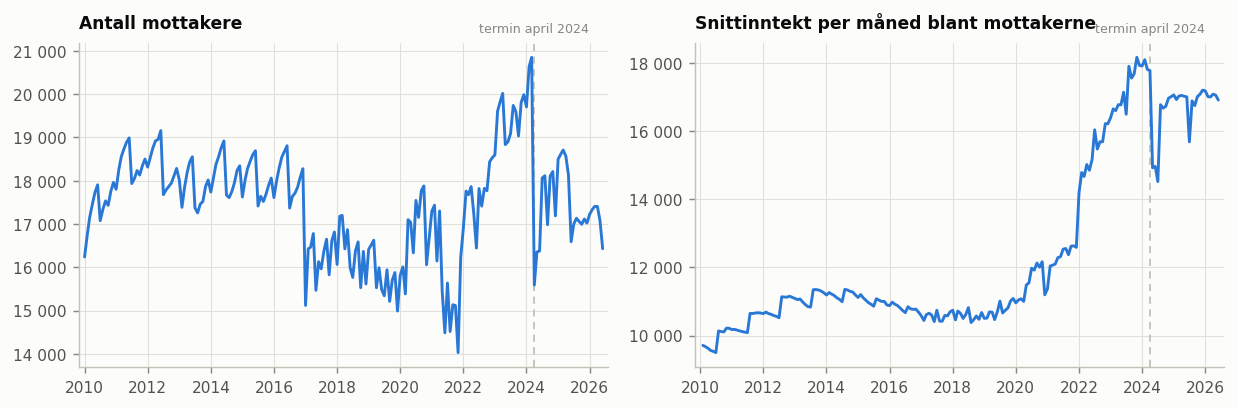

In [8]:
o = oslo[oslo.ant_husstander_termin > 0]
BRUDD = pd.Timestamp("2024-04-01")

fig, akser = plt.subplots(1, 2, figsize=(9.6, 3.2), sharex=True)
for ax, kol, tittel in zip(akser,
        ["ant_husstander_termin", "gjsnitt_inntekt_mnd"],
        ["Antall mottakere", "Snittinntekt per måned blant mottakerne"]):
    ax.plot(o.dato, o[kol], color=SERIE[0])
    ax.axvline(BRUDD, color=BASIS, lw=1.0, ls=(0, (4, 3)), zorder=1)
    ax.set_title(tittel)
    ax.margins(x=0.01)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(tusen))
    ax.annotate("termin april 2024", xy=(BRUDD, 1.0),
                xycoords=("data", "axes fraction"), xytext=(0, 4),
                textcoords="offset points", ha="center", va="bottom",
                fontsize=7, color=DEMPET, annotation_clip=False)
fig.tight_layout(); plt.show()


Venstre rute faller 25 % på én termin. Høyre rute rører seg ikke. Tabellen gir
tallene.


In [9]:
KOL = ["ant_husstander_termin", "gjsnitt_inntekt_mnd",
       "gjsnitt_boutgift_mnd", "gjsnitt_bostotte", "ant_over_tak"]
oi = o.set_index("dato")
f, e = oi.loc[pd.Timestamp("2024-03-01"), KOL], oi.loc[pd.Timestamp("2024-04-01"), KOL]

april = pd.DataFrame({"mars 2024": f.round(0), "april 2024": e.round(0),
                      "endring": (100*(e/f - 1)).round(1).astype(str) + " %"})
april.index.name = None
april


,mars 2024,april 2024,endring
ant_husstander_termin,20849.0,15588.0,-25.2 %
gjsnitt_inntekt_mnd,17824.0,17785.0,-0.2 %
gjsnitt_boutgift_mnd,12530.0,12615.0,0.7 %
gjsnitt_bostotte,3758.0,3767.0,0.2 %
ant_over_tak,17582.0,17809.0,1.3 %


### Hva figuren ikke viser

En fjerdedel av mottakerne forsvant, og ingen av de fire gjennomsnittene beveget
seg mer enn 1,3 %. De som falt ut hadde altså omtrent samme snittinntekt,
boutgift og bostøtte som de som ble igjen.

Det betyr ikke at sammensetningen var uendret. Brukergruppene er den eneste
oppløsningen av fordelingen uttrekket tilbyr, og de sier noe annet.


In [10]:
G = bgr[bgr.ant_husstander_termin > 0].pivot_table(
        index="dato", columns="brukergruppe",
        values="ant_husstander_termin", aggfunc="sum").sort_index()

gf, ge = G.loc[pd.Timestamp("2024-03-01")], G.loc[pd.Timestamp("2024-04-01")]
dek = pd.DataFrame({"mars": gf, "april": ge, "endring": (ge - gf)})
dek["prosent"]         = (100*(ge/gf - 1)).round(1)
dek["andel_av_fallet"] = (100*dek.endring/dek.endring.sum()).round(1)
dek = dek.sort_values("endring")
dek.index.name = None
assert abs(dek.endring.sum() - (e.ant_husstander_termin - f.ant_husstander_termin)) < 1
dek


,mars,april,endring,prosent,andel_av_fallet
Husstander med midlertidige trygdeytelser,6353,4428,-1925,-30.3,36.6
Uføre forøvrig,4091,2425,-1666,-40.7,31.7
Unge uføre,1344,562,-782,-58.2,14.9
Husstander uten trygdeytelser,6679,6151,-528,-7.9,10.0
Eldre,2382,2022,-360,-15.1,6.8


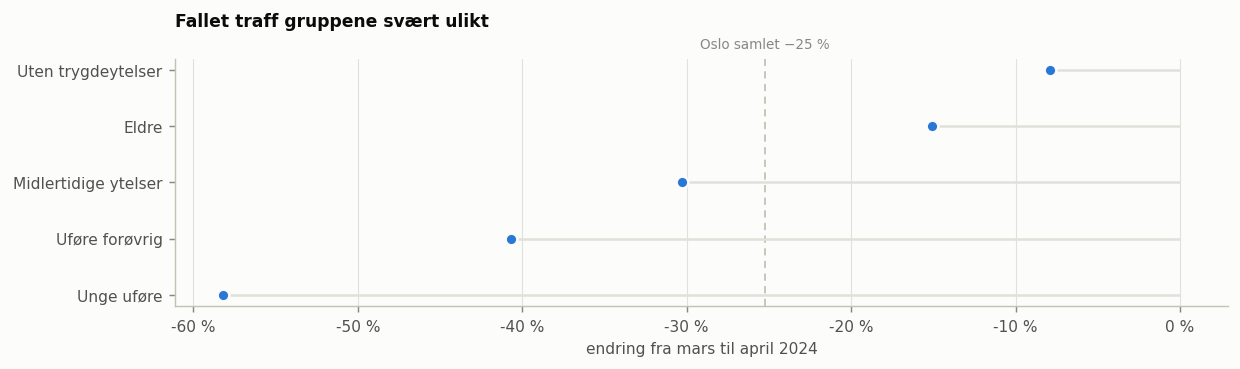

In [11]:
KORT = {"Husstander med midlertidige trygdeytelser": "Midlertidige ytelser",
        "Husstander uten trygdeytelser": "Uten trygdeytelser",
        "Uføre forøvrig": "Uføre forøvrig", "Unge uføre": "Unge uføre",
        "Eldre": "Eldre"}

d = dek.sort_values("prosent")
fig, ax = plt.subplots(figsize=(9.6, 2.9))
y = np.arange(len(d))
ax.hlines(y, 0, d.prosent, color=RUTE, lw=1.4)
ax.plot(d.prosent, y, "o", ms=6.5, color=SERIE[0],
        markeredgecolor="#fcfcfb", markeredgewidth=1.4, zorder=3)
ax.axvline(100*(e.ant_husstander_termin/f.ant_husstander_termin - 1),
           color=BASIS, lw=1.0, ls=(0, (4, 3)), zorder=1)
ax.set_yticks(y, [KORT[i] for i in d.index])
ax.set_xlabel("endring fra mars til april 2024")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f} %"))
ax.grid(axis="y", visible=False)
ax.set_title("Fallet traff gruppene svært ulikt", pad=18)
oslo_pst = 100*(e.ant_husstander_termin/f.ant_husstander_termin - 1)
etikett = f"Oslo samlet {oslo_pst:.0f} %".replace("-", chr(8722))
ax.annotate(etikett, xy=(oslo_pst, 1.0),
            xycoords=("data", "axes fraction"), xytext=(0, 4),
            textcoords="offset points", ha="center", va="bottom",
            fontsize=7.5, color=DEMPET, annotation_clip=False)
fig.tight_layout(); plt.show()


### Hva det betyr

Unge uføre mistet nesten seks av ti mottakere, husstander uten trygdeytelser åtte
prosent. Sammensetningen ble bygget om, og ingen av gjennomsnittene fanget det.

Utgangen var altså sterkt selektert på ytelsesgruppe, men omtrent proporsjonal
gjennom inntektsfordelingen. Ytelsesgruppe og inntekt henger dermed ikke tett
sammen i denne populasjonen — rimelig, siden det midlertidige regelverket flyttet
både inntektsgrensene og boutgiftstaket, slik at retten avhang av kombinasjonen
framfor av inntekt alene.

Det generelle: et snitt over en gruppe hvis grense settes av regelverket,
beskriver grensen mer enn menneskene innenfor. To ulike fordelinger kan gi samme
snitt, og aggregatet kan ikke skille dem. Derfor står brukergruppeinndelingen ved
siden av ethvert snitt i det som følger, og derfor kan ikke snittvariablene brukes
som prediktorer: de bestemmes av de samme regelendringene som utfallet.


### Sammensetningen endret seg også mellom Oslo og landet

Uttrekket har de samme seriene nasjonalt. Sammenlikningen viser at oppbyggingen
2021–2024 ikke traff likt.


In [12]:
def total(fil):
    d = pd.read_csv(RAW + fil)
    d["dato"] = pd.to_datetime(dict(year=d.aar, month=d.manedsnr, day=1))
    return (d[d.ant_husstander_termin > 0]
            .groupby("dato")["ant_husstander_termin"].sum())

o_tot = total(FILER[0])
n_tot = total("husbanken_bostotte_nasjonalt_manedlig.csv")
andel = (o_tot / n_tot * 100).dropna()
aarlig = andel.groupby(andel.index.year).mean().round(2)

print("Oslos andel av mottakerne nasjonalt, prosent, arsgjennomsnitt:")
for aar in [2010, 2015, 2019, 2021, 2022, 2023, 2024, 2025, 2026]:
    if aar in aarlig.index:
        print(f"  {aar}   {aarlig[aar]:5.2f}")
print(f"\n  2010 til 2021 : {aarlig[2021] - aarlig[2010]:+5.2f} pp")
print(f"  2021 til 2024 : {aarlig[2024] - aarlig[2021]:+5.2f} pp")

ng = pd.read_csv(RAW + "husbanken_bostotte_nasjonalt_brukergruppe_manedlig.csv")
ng["dato"] = pd.to_datetime(dict(year=ng.aar, month=ng.manedsnr, day=1))
NG = ng[ng.ant_husstander_termin > 0].pivot_table(
        index="dato", columns="brukergruppe",
        values="ant_husstander_termin", aggfunc="sum").sort_index()

m21, m24 = pd.Timestamp("2021-03-01"), pd.Timestamp("2024-03-01")
vekst = pd.DataFrame({
    "Oslo %":      (100*(G.loc[m24]/G.loc[m21] - 1)).round(0),
    "nasjonalt %": (100*(NG.loc[m24]/NG.loc[m21] - 1)).round(0),
})
vekst.index = [KORT[i] for i in vekst.index]
vekst.index.name = None
print("\nVekst mars 2021 til mars 2024:")
print(vekst.to_string())


Oslos andel av mottakerne nasjonalt, prosent, arsgjennomsnitt:
  2010   14.43
  2015   16.86
  2019   19.07
  2021   19.93
  2022   18.65
  2023   18.18
  2024   18.49
  2025   18.55
  2026   18.46

  2010 til 2021 : +5.50 pp
  2021 til 2024 : -1.44 pp

Vekst mars 2021 til mars 2024:
                      Oslo %  nasjonalt %
Eldre                   33.0         26.0
Midlertidige ytelser    44.0         72.0
Uten trygdeytelser       4.0         21.0
Uføre forøvrig          45.0         87.0
Unge uføre              88.0         50.0


Oslos andel steg hvert år fra 2010 til 2021, fra 14,4 % til 19,9 %, og falt så
til rundt 18,5 %. Nasjonalt vokste gruppen med midlertidige trygdeytelser 72 %
fra 2021 til 2024, mot 44 % i Oslo.

SØF-rapport 05/2025 oppgir at ukrainske husstander gikk fra 0,1–0,2 % av
mottakerne i 2020–21 til 13,5 % i 2024. Bosettingen skjedde i hovedsak utenfor
Oslo, og det er en nærliggende forklaring på fallet i andelen. Tallet fra SØF har
jeg ikke kontrollert mot rapporten selv; andelene over er regnet i cellen.

Det har en følge for arbeidsverk 1. M7 skalerer nasjonale forhåndsanslag ned til
Oslo med Oslos målte andel. Den andelen er ingen konstant — den flyttet seg 5,5
prosentpoeng oppover på elleve år og 1,4 nedover på tre. Andelen bør måles ved
hver prognoseopprinnelse, av samme grunn som ordensvalget gjentas der.


## 5. Kontroller

To oppdelinger av samme total. Begge skal summere til Oslo. Kontrollen kjører på
uvasket data, før sanntidskanten fjernes.


In [13]:
def sum_mot_total(df, navn):
    s = df.groupby(["aar", "manedsnr"])["ant_husstander_termin"].sum()
    t = oslo.set_index(["aar", "manedsnr"])["ant_husstander_termin"]
    felles = s.index.intersection(t.index)
    avvik  = (s[felles] - t[felles]).abs()
    print(f"{navn:14s} {len(felles):4d} måneder   {int((avvik > 0).sum())} avvik   "
          f"største {avvik.max():.0f}")
    return int((avvik > 0).sum())

feil = sum_mot_total(bydel, "bydel") + sum_mot_total(bgr, "brukergruppe")
assert feil == 0, "Oppdelingene summerer ikke til Oslo-totalen"


bydel           199 måneder   0 avvik   største 0
brukergruppe    199 måneder   0 avvik   største 0


### Hva kontrollen dekker

Alle tre uttrekkene er regnet av samme Qlik-app, med samme uttrykk over samme
faktatabell. At marginalene summerer til totalen er derfor i stor grad en
egenskap ved aggregeringen. Kontrollen fanger feil selection, feil dimensjon, og
rader som er falt bort under uttrekket. Den er ikke ekstern validering.

Den eksterne valideringen ligger i arbeidsverk 1: uttrekket målt mot Husbankens
publiserte nasjonale årstall, med avvik fra 0,00 til −2,10 % over fem år.

Én ting avgjør kontrollen likevel. `count(distinct HusstandId)` er ikke additiv
generelt — en husstand som telles i to celler samme måned ville gitt marginalsum
større enn totalen. Avviket er null i alle måneder, så klassifiseringen er entydig
per husstand og måned. Oppdelingene er da ekte partisjoner, og det er en
forutsetning for hierarkisk avstemming i notebook 05.


### Sanntidskanten

Siste måned i uttrekket er strukturell null: terminkjøringen er ikke gjort. Den
fjernes, som vaskeinngrep V1 i arbeidsverk 1.


In [14]:
print(oslo[["dato", "ant_husstander_termin"]].tail(3).to_string(index=False))

vask_v1 = lambda df: df[df.ant_husstander_termin > 0].reset_index(drop=True)
oslo_v, bydel_v, bgr_v = vask_v1(oslo), vask_v1(bydel), vask_v1(bgr)
print(f"\netter V1: {oslo_v.dato.min():%Y-%m} – {oslo_v.dato.max():%Y-%m}, "
      f"{oslo_v.dato.nunique()} måneder")


      dato  ant_husstander_termin
2026-05-01                  17075
2026-06-01                  16428
2026-07-01                      0

etter V1: 2010-01 – 2026-06, 198 måneder


## 6. Panelet

Hvor mye data maskinlæringen har, avgjør hvilke modellklasser som er forsvarlige.


In [15]:
T     = oslo_v.dato.nunique()
noder = sorted(bydel_v.kommunenr.unique())
BYDEL = [k for k in noder if k != "0301"]        # 0301 er ufordelt restnode
K_b, K_g = len(BYDEL), bgr_v.brukergruppe.nunique()
N_SERIER = 1 + len(noder) + K_g
N_OBS    = N_SERIER * T

print(f"måneder (T)                     : {T}")
print(f"bydeler                         : {K_b}   (+ restnode 0301)")
print(f"brukergrupper                   : {K_g}")
print(f"serier i hierarkiet             : {N_SERIER}")
print(f"observasjoner i marginalpanelet : {tusen(N_OBS)}")


måneder (T)                     : 198
bydeler                         : 15   (+ restnode 0301)
brukergrupper                   : 5
serier i hierarkiet             : 22
observasjoner i marginalpanelet : 4 356


Nodetallet er ikke det samme som informasjonsmengden. Bydelene og brukergruppene
er to oppdelinger av samme total, og hver oppdeling summerer til den samme serien.
Cellen regner hvor mange uavhengige retninger variasjonen har, før og etter at
byens felles bevegelse er trukket ut.


In [16]:
def bredt(df, kol):
    return (df.pivot_table(index="dato", columns=kol,
                           values="ant_husstander_termin", aggfunc="sum")
              .sort_index())

B  = bredt(bydel_v, "kommunenr")[BYDEL]
navn = (bydel_v[["kommunenr", "bydel"]].drop_duplicates()
        .set_index("kommunenr")["bydel"])

vekst      = np.log(B.where(B > 0)).diff().dropna()
vekst_oslo = (np.log(oslo_v.set_index("dato")["ant_husstander_termin"])
              .diff().reindex(vekst.index))

# Deltakelsesforholdet til egenverdiene: hvor mange uavhengige retninger som
# bærer variasjonen. Verdi 1 betyr at alle seriene beveger seg som én.
def effektiv_dimensjon(X):
    p = np.linalg.eigvalsh(X.corr().values)[::-1]
    p = p / p.sum()
    return X.corr(), 1 / (p ** 2).sum(), p[0]

R0, d0, p0 = effektiv_dimensjon(vekst)

X    = np.column_stack([np.ones(len(vekst_oslo)), vekst_oslo.values])
rest = pd.DataFrame(vekst.values - X @ np.linalg.lstsq(X, vekst.values, rcond=None)[0],
                    index=vekst.index, columns=vekst.columns)
R1, d1, _ = effektiv_dimensjon(rest)
r2 = 1 - rest.var() / vekst.var()

par = lambda R: np.median(R.values[np.triu_indices_from(R.values, 1)])
print(f"median parvis korrelasjon, vekst   : {par(R0):.2f}")
print(f"første komponent forklarer          : {p0:.1%}")
print(f"EFFEKTIV DIMENSJON, rå vekst        : {d0:.1f}  av {K_b}")
print()
print(f"Oslo-totalen forklarer av bydelsvekst: median {r2.median():.1%}   "
      f"spenn {r2.min():.1%} – {r2.max():.1%}")
print()
print(f"median parvis korrelasjon, rest     : {par(R1):.2f}")
print(f"EFFEKTIV DIMENSJON, etter fellesledd: {d1:.1f}  av {K_b}")


median parvis korrelasjon, vekst   : 0.92
første komponent forklarer          : 91.8%
EFFEKTIV DIMENSJON, rå vekst        : 1.2  av 15

Oslo-totalen forklarer av bydelsvekst: median 93.0%   spenn 79.7% – 97.1%

median parvis korrelasjon, rest     : -0.06
EFFEKTIV DIMENSJON, etter fellesledd: 11.3  av 15


Restleddet har altså mange uavhengige retninger. Neste spørsmål er om det bærer
informasjon, eller bare er små tall. Cellen regner hvordan restvariasjonen
skalerer med bydelens størrelse.


In [17]:
n  = B.loc["2024":].mean()
sd = rest.std()

# Var restleddet uavhengig telling hver måned, ville standardavviket i
# logendring vært sqrt(2/n). Sammenlikningen viser om det stemmer.
gulv = np.sqrt(2 / n)

A  = np.column_stack([np.ones(K_b), np.log(n.values)])
b  = np.linalg.lstsq(A, np.log(sd.values), rcond=None)[0]
res = np.log(sd.values) - A @ b

skala = pd.DataFrame({
    "mottakere": n.round(0),
    "sd_rest_%": (100*sd).round(2),
    "tellegulv_%": (100*gulv).round(2),
    "andel_av_gulv": (sd/gulv).round(2),
}).sort_values("mottakere")
skala.index = [navn[i] for i in skala.index]
print(skala.to_string())
print()
print(f"log(sd_rest) = {b[0]:.2f} {b[1]:+.2f} · log(n)")
print(f"  helning {b[1]:+.2f}   (−0,50 = ren skalering med 1/sqrt(n))")
print(f"  R²      {1 - res.var()/np.log(sd.values).var():.2f}   over {K_b} bydeler")


                   mottakere  sd_rest_%  tellegulv_%  andel_av_gulv
Ullern                 426.0       2.60         6.85           0.38
Vestre Aker            601.0       1.75         5.77           0.30
Nordre Aker            743.0       1.55         5.19           0.30
Nordstrand             745.0       1.39         5.18           0.27
Grorud                 884.0       1.40         4.76           0.29
Bjerke                 980.0       1.53         4.52           0.34
Østensjø              1011.0       1.43         4.45           0.32
Alna                  1173.0       1.17         4.13           0.28
Stovner               1191.0       1.15         4.10           0.28
St. Hanshaugen        1265.0       1.40         3.98           0.35
Søndre Nordstrand     1265.0       1.28         3.98           0.32
Frogner               1387.0       1.36         3.80           0.36
Sagene                1913.0       0.86         3.23           0.27
Grunerløkka           2027.0       0.81         

### Hva tallene betyr

**I rå form er panelet ikke 15 serier.** Effektiv dimensjon er 1,2 av 15. Første
hovedkomponent forklarer over 90 % av variasjonen i logvekst, og median parvis
korrelasjon mellom bydeler er 0,92. En global modell som får dette panelet uten
videre, tilpasser det samme signalet femten ganger.

Fellesbevegelsen kommer av at både regelverkskalenderen og utbetalingskalenderen
er nasjonale og treffer alle bydeler samme måned. Kalenderen virker hver eneste
måned, og bærer derfor mest.

**Restleddet er en størrelseseffekt, ikke en bydelseffekt.** Trekker man ut byens
bevegelse, faller median parvis korrelasjon til om lag null og effektiv dimensjon
stiger til over 11 av 15. Men restvariasjonen skalerer med hvor mange mottakere
bydelen har: helningen er nær −0,6, og 87 % av forskjellen mellom bydeler
forklares av størrelse alene. Ullern har færrest mottakere og størst restledd,
Grünerløkka flest og minst.

Tellegulvet er samtidig lærerikt ved å være feil. Var hver måned en uavhengig
telling, ville restleddet vært rundt elleve ganger større enn det er. Serien er en
beholdning: de fleste husstandene blir stående fra måned til måned, og bare
strømmen inn og ut varierer.

**Følgen for modellvalget.** De elleve retningene er reelle, men tynne. Det
svekker argumentet for at en global modell har mye å lære på bydelsnivå, og det
styrker argumentet for avstemming, siden MinT nettopp er bygget for støyende
bunnserier. Fellesbevegelsen hører til den strukturelle modellen fra arbeidsverk 1,
som kjenner regelkalenderen.


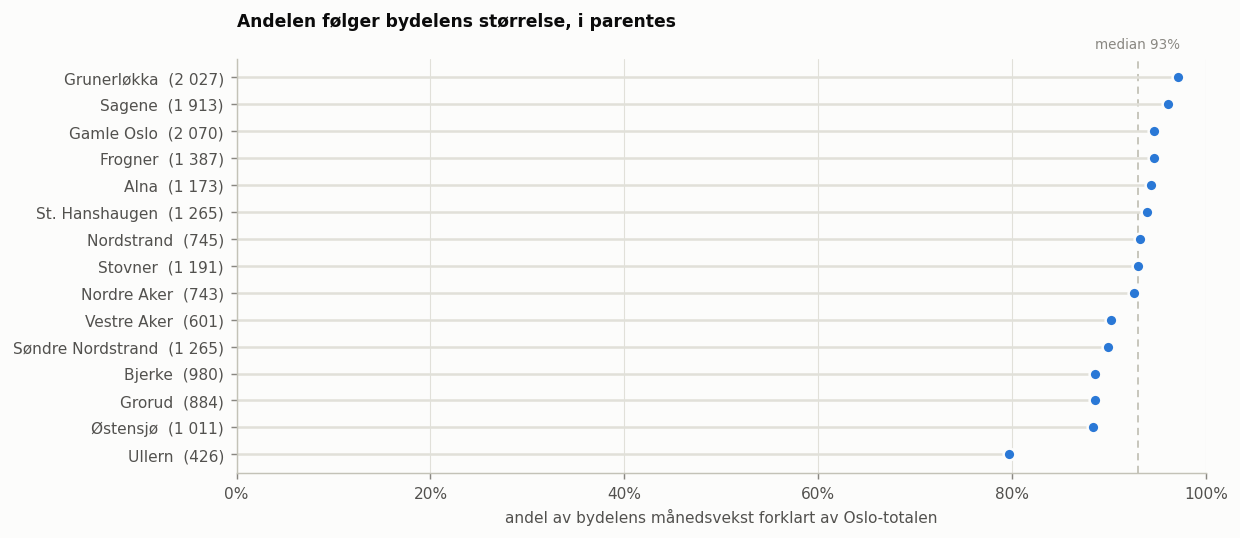

In [18]:
d = r2.sort_values()
fig, ax = plt.subplots(figsize=(9.6, 4.2))
y = np.arange(len(d))
ax.hlines(y, 0, d.values, color=RUTE, lw=1.4)
ax.plot(d.values, y, "o", ms=6.5, color=SERIE[0],
        markeredgecolor="#fcfcfb", markeredgewidth=1.4, zorder=3)
ax.axvline(d.median(), color=BASIS, lw=1.0, ls=(0, (4, 3)), zorder=1)
ax.set_yticks(y, [f"{navn[i]}  ({n[i]:,.0f})".replace(",", HARDT) for i in d.index])
ax.set_xlim(0, 1.0)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.grid(axis="y", visible=False)
ax.set_xlabel("andel av bydelens månedsvekst forklart av Oslo-totalen")
ax.set_title("Andelen følger bydelens størrelse, i parentes", pad=18)
ax.annotate(f"median {d.median():.0%}", xy=(d.median(), 1.0),
            xycoords=("data", "axes fraction"), xytext=(0, 4),
            textcoords="offset points", ha="center", va="bottom",
            fontsize=7.5, color=DEMPET, annotation_clip=False)
fig.tight_layout(); plt.show()


### Krysstabellen

Husbankens Qlik-app gir også bydel × brukergruppe. Uttrekket per 4. august
inneholder den ikke. Et diagnoseuttrekk 7. august 2026 ga:

| | |
|---|---|
| bunnceller | 77 (15 bydeler × 5 grupper + restnode 0301) |
| måneder | 198, 2010m1–2026m6 |
| observasjoner | 14 879 |
| celler med full månedsdekning | 75 av 77 |
| avvik mot Oslo-totalen | 0 av 198 |
| avvik mot bydelsmarginalen | 0 av 2 997 |
| avvik mot brukergruppemarginalen | 0 av 990 |

Det tar panelet fra rundt 4 000 til rundt 15 000 observasjoner, og krysscellene
blir observert i stedet for utledet. Diagnoseuttrekket viste også at ingen av de
198 månedene hadde endret verdi siden 4. august.

Krysstabellen tas i bruk fra neste daterte uttrekk, slik at begge arbeidsverk
bygger på samme dato. To spørsmål må løses først. Restnoden 0301 har to
kryssceller med 8 og 21 måneders dekning, som er for kort til å prognostiseres og
nok til å forstyrre et kovariansestimat i avstemmingen. Og API-et leverer
uprikkede celler: 26 av 14 879 har verdien 1. Dataene er offentlig tilgjengelige
uten autentisering, så det er ingen ny utlevering, men en celle som ligger stabilt
lavt over mange måneder i én bydel og én brukergruppe gjør det mulig å følge en
husstand over tid. En undertrykkingsregel må derfor se på vedvarenhet i tillegg
til cellestørrelse.


### Brukergruppene over tid

Figuren indekserer hver gruppe til desember 2021, da det midlertidige regelverket
trådte i kraft. Tabellen under gir gulvet: en gruppes månedsbevegelse i rolige
måneder, altså hvor stort et utslag må være for å bety noe.


In [19]:
iv   = pd.read_csv("data/clean/intervensjonstabell.csv")
kant = pd.to_datetime(
    pd.Series(pd.concat([iv.termin_fra, iv.termin_til]).dropna().unique()) + "-01").values

gv    = np.log(G).diff().dropna()
mnd   = gv.index.values.astype("datetime64[D]")
naer  = np.array([bool((np.abs((m - kant.astype("datetime64[D]")).astype(int)) <= 92).any())
                  for m in mnd])

gulv = pd.DataFrame({
    "mottakere":        G.loc["2025":].mean().round(0),
    "sd_rolige_mnd_%":  (100*gv[~naer].std()).round(1),
    "april_2024_%":     (100*(G.loc[pd.Timestamp("2024-04-01")] /
                              G.loc[pd.Timestamp("2024-03-01")] - 1)).round(1),
})
gulv["utslag_i_sd"] = (gulv["april_2024_%"].abs() / gulv["sd_rolige_mnd_%"]).round(1)
gulv.index = [KORT[i] for i in gulv.index]
gulv.index.name = None
gulv


,mottakere,sd_rolige_mnd_%,april_2024_%,utslag_i_sd
Eldre,2278.0,2.2,-15.1,6.9
Midlertidige ytelser,5766.0,8.8,-30.3,3.4
Uten trygdeytelser,5996.0,5.1,-7.9,1.5
Uføre forøvrig,2905.0,4.3,-40.7,9.5
Unge uføre,515.0,5.6,-58.2,10.4


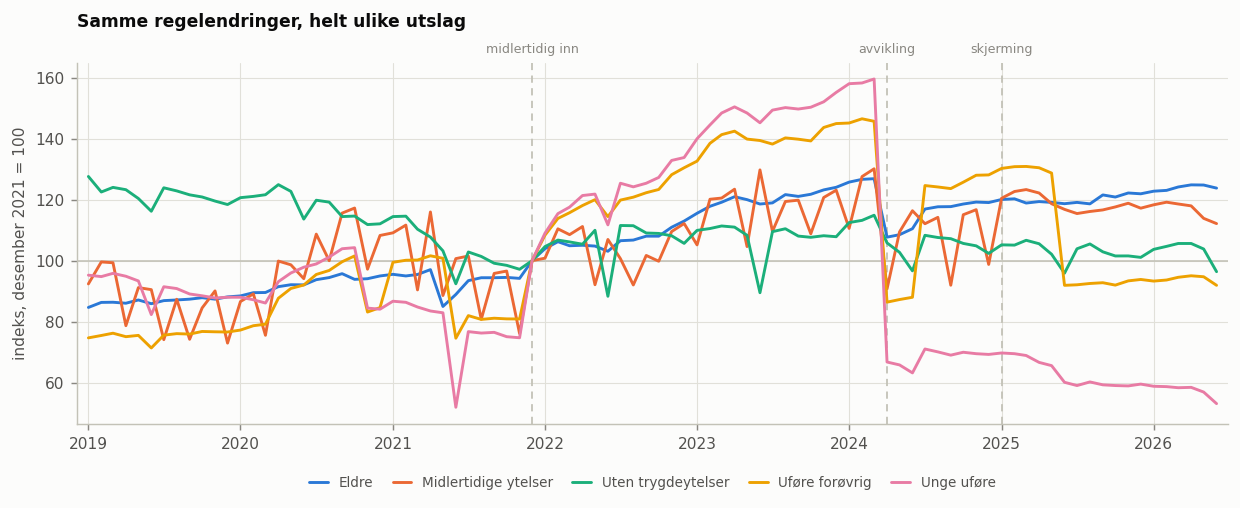

In [20]:
REF = pd.Timestamp("2021-12-01")
Gi  = (G.div(G.loc[REF]) * 100).loc["2019":]
Gi  = Gi[Gi.iloc[-1].sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(9.6, 4.0))
for (nvn, serie), farge in zip(Gi.items(), SERIE):
    ax.plot(Gi.index, serie, color=farge, label=KORT[nvn])
ax.axhline(100, color=BASIS, lw=0.9, zorder=1)
for dd, tekst in [(REF, "midlertidig inn"),
                  (pd.Timestamp("2024-04-01"), "avvikling"),
                  (pd.Timestamp("2025-01-01"), "skjerming")]:
    ax.axvline(dd, color=BASIS, lw=1.0, ls=(0, (4, 3)), zorder=1)
    ax.annotate(tekst, xy=(dd, 1.0), xycoords=("data", "axes fraction"),
                xytext=(0, 4), textcoords="offset points", ha="center",
                va="bottom", fontsize=7, color=DEMPET, annotation_clip=False)
ax.set_ylabel("indeks, desember 2021 = 100")
ax.set_title("Samme regelendringer, helt ulike utslag", pad=20)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.11), ncols=5,
          labelcolor=BLEKK_2, handlelength=1.4, columnspacing=1.4)
ax.margins(x=0.01)
fig.tight_layout(); plt.show()


Unge uføre er den minste gruppen, så linja svinger mest der uten at det trenger å
bety noe. Tabellen over skiller. Aprilutslaget er fra 1,5 til 10,4 ganger
gruppens normale månedsbevegelse i rolige måneder. Fire av fem ligger klart
utenfor det vanlige månedene produserer.

Den femte gjør det ikke. Husstander uten trygdeytelser falt 7,9 %, som er 1,5
ganger gruppens eget standardavvik. Det utslaget lar seg ikke skille fra normal
variasjon på dette grunnlaget alene, og skal derfor ikke leses som at avviklingen
traff gruppen svakt — bare som at figuren ikke kan avgjøre det.


## 7. Hva datamengden tillater

Modellvalget i notebook 03–05 følger av tallene i avsnitt 6. Fire resultater fra
litteraturen setter rammen.

**Globale modeller.** Montero-Manso & Hyndman (2021, *IJF* 37(4)) viser at en
global modell ikke er mer restriktiv enn lokale, og at gevinsten kommer av at
kompleksiteten kan skaleres med panelstørrelsen. De empiriske panelene i den
litteraturen ligger i hundreklassen. Her er K ≈ 20 før krysstabellen, fordelt på
to oppdelinger av samme total, og restleddet er i hovedsak en størrelseseffekt.

**Ekstrapolering.** Januschowski m.fl. (2022, *Forecasting with trees*, *IJF*
38(4)) dokumenterer at trebaserte modeller ikke ekstrapolerer utenfor
treningsområdet. Med nivåskift og trend flater prognosen ut ved siste observerte
nivå. Gradientboosting kjører derfor på differanser eller vekstrater i notebook 03.

**Residualmodellering.** Taşkaya-Temizel & Casey (2005, *Neural Networks*
18(5–6)) viser at kombinasjoner der ML modellerer en lineær modells residualer kan
prestere vesentlig dårligere enn komponentene hver for seg. Er RegARIMA-modellen
riktig spesifisert, er residualene nær hvit støy. Smyls ES-RNN, som vant M4 (2020,
*IJF* 36(1)), estimerte per-serie-nivå og et delt globalt nettverk sammen.
Notebook 03 kjører residual-ML som forhåndsregistrert negativ kontroll.

**Arkitekturvalg.** DeepAR (Salinas m.fl. 2020) og Temporal Fusion Transformer
(Lim m.fl. 2021) er validert på paneler med tusenvis av serier. Zeng m.fl. (AAAI
2023) viser at ett lineært lag slår flere transformer-varianter på standard
benchmarks. N-BEATS er dokumentert i sterkt redusert konfigurasjon, og via
zero-shot-overføring fra M4-forhåndstrening (Oreshkin m.fl., AAAI 2021).

Nevrale nett kjøres i notebook 04, med den forventede utgangen skrevet inn i
«faller dersom»-tabellen før estimering.


## 8. Hva kategoriene skjuler

*Til Torkild: skrives ut i din egen stemme. Punktene er innholdet.*

1. **Modellen ser ytelser.** Brukergruppene er administrative: eldre, unge uføre,
   uføre forøvrig, husstander med midlertidige trygdeytelser, husstander uten
   trygdeytelser. Ingen av dem sier noe om helse eller livssituasjon. NAVs
   diagnosestatistikk viser at kategoriene i stor grad er helsekategorier med en
   administrativ merkelapp, og rusdiagnoser publiseres ikke som egen gruppe.
   NOU 2022:10 foreslår å erstatte uførekriteriet i kommunenes fordelingsnøkkel
   med rus- og psykisk helse-diagnoser fra Norsk pasientregister.
2. **Tallet finnes ikke.** Ingen norsk kilde tallfester rus eller psykisk helse
   blant bostøttemottakere. Husbankens register har ingen slik variabel, og
   koblinger må gå via aggregerte bydelsandeler fra Helsedirektoratet, altså
   økologiske sammenhenger.
3. **Kategoriene fanger heller ikke innvandringsstatus.** Nasjonalt gikk
   ukrainske husstander fra 0,1–0,2 % av mottakerne i 2020–21 til 13,5 % i 2024
   (SØF 05/2025). I dataene her ser man bare at gruppen med midlertidige
   trygdeytelser vokste 72 % nasjonalt mot 44 % i Oslo. Den største
   sammensetningsendringen i perioden er usynlig i variablene.
4. **Serien måler mottak.** SSB anslår at rundt halvparten til to tredjedeler av
   de berettigede mottok bostøtte i 2016, med Oslo høyest blant storbyene.
   Ekspertgruppen fra 2022 beskriver regelverket som vanskelig å forstå. Take-up
   er selv en størrelse som beveger seg.
5. **Take-up beveger seg tregt.** Litteraturen om administrativ byrde peker på
   friksjon og kompleksitet som forklaring på ikke-bruk, og på at byrden rammer
   hardest der behovet er størst. Etter den norske reformen i 2009 ble faktisk
   opptak klart lavere enn anslått. Britiske evalueringer av satsendringer finner
   at atferdstilpasningen først slår ut etter omtrent elleve måneder.
6. **Konsekvensen for modellen.** Litteraturen predikerer asymmetrisk innfasing:
   gradvis inn over seks til tolv måneder når en regel utvider kretsen, skarpt ut
   når den innskrenker den mekanisk. Aprilfallet i avsnitt 4 er den skarpe siden
   av det. Arbeidsverk 1 har asymmetriproposisjonen med en tre måneders rampe
   testet mot AICc; nå følger en forventet størrelsesorden av litteraturen.
7. **Konsekvensen for bruken.** En modell på aggregerte månedstall for
   kapasitetsplanlegging er noe annet enn en modell som scorer enkeltpersoner.
   Notebook 06 tar det.


### Kildestatus

«Kontrollert i kildesøk» betyr at et søk oppgir å ha lest primærkilden, uten at
jeg har åpnet den selv.

| Kilde | Bruk i avsnitt 8 | Status |
|---|---|---|
| SSB Rapporter 2019/02 (Revold & With) | take-up 50–61 %, Oslo høyest | kontrollert mot primærkilde |
| Ekspertgruppen 2022 (von der Fehr m.fl.), KDD | regelverkets kompleksitet | kontrollert i kildesøk |
| NIBR 2021:10 (Dyb & Zeiner) | rus og psykisk helse blant bostedsløse | kontrollert i kildesøk |
| Velferdsetaten, Helhetlig russtatistikk 2026 | kartleggingen uke 48/2024 | kontrollert i kildesøk |
| SØF-rapport 05/2025 (Nyhus, Smedsvik & Haraldsvik) | ingen rusdata i registrene; ~25 000 husstander ut ved avviklingen | kontrollert i kildesøk |
| NAV, diagnosestatistikk uføre og AAP | hva kategoriene skjuler | ikke verifisert |
| NOU 2022:10 | forslag om diagnosekriterium | ikke verifisert |
| NOVA/Fafo 2011, 2009-reformen | opptak lavere enn anslått | kontrollert i kildesøk |
| DWP Research Report 874 (2014) | elleve måneders treghet | kontrollert i kildesøk |
| Christensen m.fl. 2020, *PAR* 80 | administrativ byrde | kontrollert i kildesøk |
| Bhargava & Manoli 2015, *AER* 105(11) | friksjon som forklaring | kontrollert i kildesøk |

De to uverifiserte radene står uten tall i teksten over.


## 9. Hva notebooken ikke gjør

- Ingen modell er estimert. Baselinen M0–M7 ligger i arbeidsverk 1 og hentes inn
  i notebook 02 gjennom eksportfilene derfra.
- Krysstabellen er kontrollert, men hører til et annet uttrekk. Den tas i bruk
  fra neste daterte uttrekk.
- Protokollkontrakten er ikke lest inn. Den krever at arbeidsverk 1 rendres med
  eksportchunken. Notebook 02 skal stoppe hvis den mangler.
- Fordelingen er bare oppløst i brukergruppedimensjonen. Uttrekket tilbyr ikke
  mer, og inntektsfordelingen innad i en gruppe er ikke observert.
- De to uverifiserte kildene står uten tall.

### Kjøremanifest


In [21]:
MANIFEST["seed"] = SEED
MANIFEST["data"] = {
    "maaneder": int(T), "bydeler": int(K_b), "brukergrupper": int(K_g),
    "serier": int(N_SERIER), "obs_marginalpanel": int(N_OBS),
    "forste_maaned": f"{oslo_v.dato.min():%Y-%m}",
    "siste_maaned":  f"{oslo_v.dato.max():%Y-%m}",
}
MANIFEST["funn"] = {
    "effektiv_dimensjon_raa": round(float(d0), 2),
    "effektiv_dimensjon_betinget": round(float(d1), 2),
    "r2_oslo_median": round(float(r2.median()), 3),
    "skalering_helning": round(float(b[1]), 2),
    "april2024_antall_pst": round(float(100*(e.ant_husstander_termin /
                                             f.ant_husstander_termin - 1)), 1),
    "april2024_snittinntekt_pst": round(float(100*(e.gjsnitt_inntekt_mnd /
                                                   f.gjsnitt_inntekt_mnd - 1)), 1),
}
MANIFEST["kontroller"] = {"kalenderidentitet": "ok", "summering": "ok",
                          "vask_v1": "ok", "sjekksum": "beregnet"}
print(json.dumps(MANIFEST, indent=2, ensure_ascii=False))


{
  "commit": "9b3da3e",
  "uttrekk": "2026-08-04",
  "python": "3.11.15",
  "pakker": {
    "numpy": "2.4.4",
    "pandas": "3.0.2",
    "sklearn": "1.8.0",
    "scipy": "1.17.1",
    "matplotlib": "3.10.9"
  },
  "sjekksum": {
    "husbanken_bostotte_oslo_manedlig.csv": "5e741e0864bd8d666057b627170ebf0b47229ea846f0ed98717cc5bc590600d6",
    "husbanken_bostotte_oslo_bydel_manedlig.csv": "d5dcd738bb9e23cc9c5f9e53d27ed591f658f796c77d3de6001db226abaedee9",
    "husbanken_bostotte_oslo_brukergruppe_manedlig.csv": "3b0f170c2e876364bc1e902085fc223820d1654aa13b9829ce8d3216c8ab69dd"
  },
  "seed": 20260807,
  "data": {
    "maaneder": 198,
    "bydeler": 15,
    "brukergrupper": 5,
    "serier": 22,
    "obs_marginalpanel": 4356,
    "forste_maaned": "2010-01",
    "siste_maaned": "2026-06"
  },
  "funn": {
    "effektiv_dimensjon_raa": 1.19,
    "effektiv_dimensjon_betinget": 11.33,
    "r2_oslo_median": 0.93,
    "skalering_helning": -0.6,
    "april2024_antall_pst": -25.2,
    "april2024_s